# Le marché en direct

## La question

Les relevés de paris permettent de voir **comment l'argent se place avant le départ**, et
comment ce placement bouge. Trois questions concrètes :

1. Le public a-t-il du nez ? Autrement dit, l'argent qui arrive tard désigne-t-il mieux le
   vainqueur que l'argent du matin ?
2. Certaines courses sont-elles plus « parlantes » que d'autres — plus d'enjeux, plus de
   mouvement, un favori qui vacille ?
3. Comment les cotes évoluent-elles dans les heures qui précèdent le top ?

Ce n'est pas un fichier de parieurs identifiés. On ne voit pas M. Dupont. On voit la foule :
combien d'euros sur quel cheval, à quel instant. Les « clusters » que l'on peut former sont
donc des **manières de parier**, pas des personnes.

La table ne couvre pas vingt mois d'histoire. Elle ne contient que les courses **suivies en
direct**. Le panorama précédent l'avait déjà signalé ; ici, on la prend pour ce qu'elle est.

## Sommaire

1. [De quoi est faite cette table](#table)
2. [Quelle portion du calendrier est vraiment observée](#couverture)
3. [Où va l'argent, selon le type de pari](#paris)
4. [L'évolution des cotes jusqu'au départ](#temps)
5. [Le public a-t-il le nez fin ?](#nez)
6. [Quelles courses sont les plus intéressantes](#courses)
7. [Quatre visages du marché](#clusters)
8. [Verdict](#verdict)

In [22]:
import sys
import warnings
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "pmu").exists():
    project_root = project_root.parent
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import design_system as ds

warnings.filterwarnings("ignore", category=FutureWarning)
THEME = ds.apply_theme("light")

In [23]:
ESPACE = "\u202f"


def nombre(valeur, decimales=0, unite=""):
    if pd.isna(valeur):
        return "—"
    texte = f"{valeur:,.{decimales}f}".replace(",", ESPACE).replace(".", ",")
    return f"{texte}{unite}"


def tableau(frame, titre=None, formats=None, barres=None, precision=0):
    styler = frame.style.set_table_styles(ds.table_css("light"))
    if titre:
        styler = styler.set_caption(titre)
    if formats:
        styler = styler.format(formats, na_rep="—")
    else:
        styler = styler.format(precision=precision, thousands=ESPACE, decimal=",", na_rep="—")
    if barres:
        styler = styler.bar(subset=barres, color=THEME["chart_3"], align="left", height=62, width=96)
    return styler


def chiffres_cles(valeurs: dict, titre: str):
    frame = pd.DataFrame({"": list(valeurs.values())}, index=list(valeurs.keys()))
    return tableau(frame, titre, formats={"": "{}"})


def figure(titre: str, figsize=(11, 4.4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(titre)
    return fig, ax


def barres(serie, titre, xlabel="", fmt="{:,.1f}"):
    ordre = serie.sort_values()
    fig, ax = figure(titre, (10.5, max(2.8, 0.36 * len(ordre) + 1.5)))
    if ordre.min() < 0 < ordre.max():
        couleurs = [THEME["chart_2"] if valeur < 0 else THEME["primary"] for valeur in ordre]
        ax.barh([str(i) for i in ordre.index], ordre.to_numpy(dtype=float), height=0.68, color=couleurs)
        ax.axvline(0, color=THEME["foreground"], linewidth=0.8)
        etendue = float(max(abs(ordre.min()), abs(ordre.max())))
        ax.set_xlim(-etendue * 1.25, etendue * 1.25)
    else:
        ax.barh(
            [str(i) for i in ordre.index],
            ordre.to_numpy(dtype=float),
            height=0.68,
            color=THEME["primary"],
        )
        ax.set_xlim(0, float(ordre.max()) * 1.18)
    ds.annotate_bars(ax, orientation="horizontal", fmt=fmt)
    ds.rounded_bars(ax, orientation="horizontal")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)
    ax.set_xlabel(xlabel)
    return fig, ax

<a id="table"></a>
## 1. De quoi est faite cette table

Chaque enregistrement est une **photographie** : une course, un type de pari, un horodatage,
une masse d'euros, et la liste des combinaisons qui portent (presque) tout l'enjeu. Le simple
gagnant, par exemple, y apparaît comme « tel numéro, tant d'euros », répété toutes les
quelques minutes jusqu'au départ.

In [24]:
from dataset.load_combinaisons import (
    load_arrivees_marche,
    load_courses_marche,
    load_marche_simple,
    load_releves,
)

releves = load_releves()
simple = load_marche_simple()
arrivees = load_arrivees_marche()
courses = load_courses_marche()

simple = simple[simple["masse"] > 0].copy()
simple["part"] = simple["enjeu"] / simple["masse"]
simple["cote_implicite"] = 1 / simple["part"]

display(
    chiffres_cles(
        {
            "Photographies enregistrées": nombre(len(releves)),
            "Courses suivies": nombre(releves["course_id"].nunique()),
            "Types de paris": nombre(releves["type_pari"].nunique()),
            "Première course observée": f"{releves['date_programme'].min():%d/%m/%Y}",
            "Dernière course observée": f"{releves['date_programme'].max():%d/%m/%Y}",
            "Jours distincts": nombre(releves["date_programme"].nunique()),
        },
        "Le marché en direct, en un coup d'œil",
    )
)

,
Photographies enregistrées,170 353
Courses suivies,749
Types de paris,16
Première course observée,21/08/2026
Dernière course observée,12/09/2026
Jours distincts,14


<a id="couverture"></a>
## 2. Quelle portion du calendrier est vraiment observée

In [25]:
par_jour = (
    releves.groupby("date_programme")
    .agg(photographies=("id", "size"), courses=("course_id", "nunique"))
    .sort_index()
)
par_jour.index = pd.to_datetime(par_jour.index).strftime("%d/%m")
par_jour.columns = ["Photographies", "Courses suivies"]
display(
    tableau(
        par_jour,
        "Activité jour par jour : un suivi récent, avec un trou",
        formats={colonne: (lambda v: nombre(v)) for colonne in par_jour.columns},
        barres=["Photographies"],
    )
)

,Photographies,Courses suivies
date_programme,,
21/08,175,44
22/08,4 521,57
23/08,12 761,46
24/08,11 849,40
25/08,12 529,40
26/08,13 006,42
27/08,12 308,46
06/09,10 046,82
07/09,11 245,52


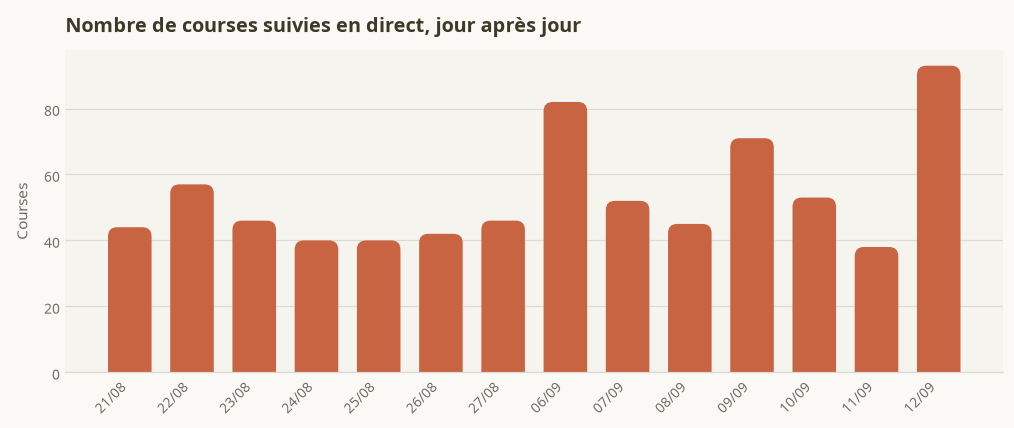

In [26]:
fig, ax = figure("Nombre de courses suivies en direct, jour après jour", (11, 3.8))
ax.bar(par_jour.index, par_jour["Courses suivies"].to_numpy(dtype=float), color=THEME["primary"], width=0.7)
ds.rounded_bars(ax)
ax.set_ylabel("Courses")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.show()

**À retenir.** On n'a pas l'histoire des cotes depuis 2025. On a **deux semaines de marché
vivant**, autour de la fin août et de la mi-septembre 2026, avec un trou d'une semaine au
milieu. C'est trop court pour une loi générale sur l'année, c'est largement assez pour voir
comment l'argent se comporte *dans les heures qui précèdent une course*. Toutes les lectures
qui suivent valent pour ce film-là, pas pour tout le calendrier.

<a id="paris"></a>
## 3. Où va l'argent, selon le type de pari

In [27]:
dernier = (
    releves.sort_values("update_time")
    .groupby(["course_id", "type_pari"], observed=True)
    .last()
    .reset_index()
)
par_pari = (
    dernier.groupby("type_pari", observed=True)
    .agg(
        courses=("course_id", "nunique"),
        photographies=("type_pari", "size"),
        masse_mediane=("masse", "median"),
        masse_totale=("masse", "sum"),
        lignes_medianes=("nombre_lignes", "median"),
    )
    .sort_values("courses", ascending=False)
)
par_pari["masse_mediane"] = par_pari["masse_mediane"] / 100
par_pari["masse_totale"] = par_pari["masse_totale"] / 100
par_pari.columns = [
    "Courses",
    "Dernières photos",
    "Masse médiane (€)",
    "Masse totale observée (€)",
    "Combinaisons listées",
]
display(
    tableau(
        par_pari,
        "À l'arrivée du marché : ce que chaque pari concentre",
        formats={
            "Courses": lambda v: nombre(v),
            "Dernières photos": lambda v: nombre(v),
            "Masse médiane (€)": lambda v: nombre(v, 0),
            "Masse totale observée (€)": lambda v: nombre(v, 0),
            "Combinaisons listées": lambda v: nombre(v, 1),
        },
        barres=["Courses"],
    )
)

,Courses,Dernières photos,Masse médiane (€),Masse totale observée (€),Combinaisons listées
type_pari,,,,,
E_SIMPLE_PLACE,695,695,8 515,8 136 793,"11,0"
E_SIMPLE_GAGNANT,664,664,4 667,4 906 745,"10,5"
E_TRIO,627,627,1 951,1 258 678,"12,0"
E_COUPLE_GAGNANT,593,593,1 389,1 438 474,"12,0"
E_COUPLE_PLACE,592,592,2 095,2 144 679,"12,0"
E_DEUX_SUR_QUATRE,335,335,1 963,1 187 637,"12,0"
E_SUPER_QUATRE,128,128,4 496,671 834,"12,0"
E_TRIO_ORDRE,93,93,974,107 128,"12,0"
E_COUPLE_ORDRE,91,91,998,154 410,"12,0"


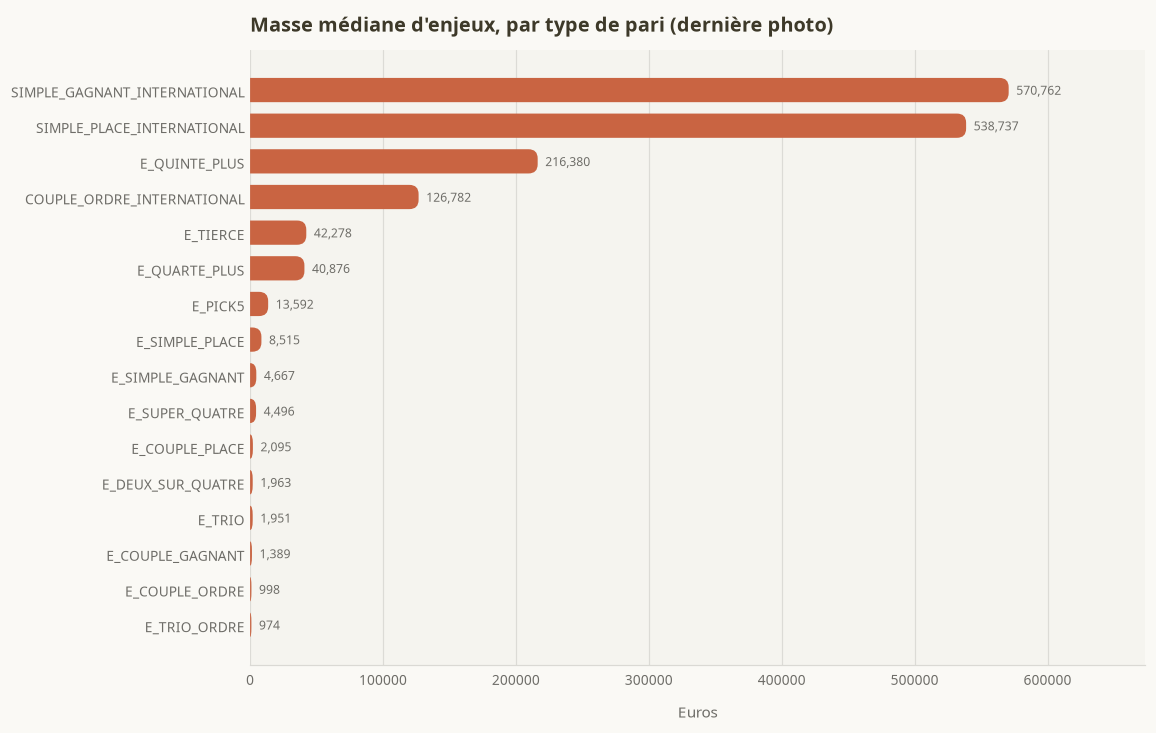

In [28]:
fig, ax = barres(
    par_pari["Masse médiane (€)"],
    "Masse médiane d'enjeux, par type de pari (dernière photo)",
    "Euros",
    fmt="{:,.0f}",
)
plt.show()

**À retenir.** Le simple gagnant et le simple placé sont presque toujours là ; le quinté, le
quarté et le tiercé ne concernent qu'une course par journée, mais y drainent des masses bien
plus lourdes. Pour suivre **l'évolution d'une cote**, le simple gagnant est l'instrument le
plus lisible : un cheval, un tas d'euros, une part du marché. C'est lui que l'on suit ensuite.

<a id="temps"></a>
## 4. L'évolution des cotes jusqu'au départ

On convertit la part d'enjeux d'un cheval en cote implicite (1 / part de la masse). Ce n'est
pas exactement la cote affichée par le PMU — le prélèvement s'en mêle — mais c'est le geste du
public, minute après minute.

In [29]:
marche = simple.merge(courses, on="course_id", how="left")
marche["minutes_avant"] = (
    pd.to_datetime(marche["heure_depart_utc"]) - pd.to_datetime(marche["instant"])
).dt.total_seconds() / 60

vainqueurs = arrivees.loc[arrivees["ordre_arrivee"] == 1, ["course_id", "num_pmu", "nom"]]
marche = marche.merge(
    vainqueurs.rename(columns={"num_pmu": "num_vainqueur", "nom": "nom_vainqueur"}),
    on="course_id",
    how="left",
)
marche["est_vainqueur"] = marche["num_pmu"] == marche["num_vainqueur"]

courses_filtrees = marche.loc[
    marche["minutes_avant"].between(0, 18 * 60) & marche["num_vainqueur"].notna(),
    "course_id",
].unique()
suivi = marche[
    marche["course_id"].isin(courses_filtrees) & marche["minutes_avant"].between(-15, 18 * 60)
].copy()

display(
    chiffres_cles(
        {
            "Courses avec simple gagnant": nombre(simple["course_id"].nunique()),
            "Courses avec vainqueur connu": nombre(suivi["course_id"].nunique()),
            "Courses encore sans arrivée": nombre(
                simple["course_id"].nunique() - suivi["course_id"].nunique()
            ),
            "Points de cote (cheval × instant)": nombre(len(suivi)),
            "Photos par course (médiane)": nombre(
                suivi.groupby("course_id")["update_time"].nunique().median(), 0
            ),
            "Fenêtre observée (médiane)": f"{nombre(suivi.groupby('course_id')['minutes_avant'].max().median(), 1)} min avant le top",
        },
        "Le film du simple gagnant",
    )
)

,
Courses avec simple gagnant,664
Courses avec vainqueur connu,359
Courses encore sans arrivée,305
Points de cote (cheval × instant),119 666
Photos par course (médiane),40
Fenêtre observée (médiane),"683,5 min avant le top"


In [30]:
# Pour ne pas comparer des courses différentes d'une fenêtre à l'autre,
# on ne garde que celles observées à la fois tôt (≥ 3 h) et tard (≤ 1 h).
longues = [
    course_id
    for course_id, bloc in suivi.groupby("course_id", observed=True)
    if bloc["minutes_avant"].max() >= 180 and bloc["minutes_avant"].min() <= 60
]
continu = suivi[suivi["course_id"].isin(longues)].copy()
bornes = [0, 10, 30, 60, 120, 180, 360, 720]
libelles = ["10 min", "30 min", "1 h", "2 h", "3 h", "6 h", "12 h"]
continu["fenetre"] = pd.cut(continu["minutes_avant"], bins=bornes, labels=libelles, right=True)

dernier_fenetre = (
    continu.sort_values("update_time")
    .groupby(["course_id", "fenetre"], observed=True)
    .last()
    .reset_index()
)
vainqueur_fenetre = (
    dernier_fenetre[dernier_fenetre["est_vainqueur"]]
    .groupby("fenetre", observed=True)["part"]
    .agg(["median", "mean", "size"])
)
vainqueur_fenetre.columns = ["Part médiane du vainqueur", "Part moyenne", "Courses"]
vainqueur_fenetre["Part médiane du vainqueur"] *= 100
vainqueur_fenetre["Part moyenne"] *= 100
display(
    tableau(
        vainqueur_fenetre,
        "Quelle part du marché le futur vainqueur occupe-t-il, à mesure que l'heure approche ?",
        formats={
            "Part médiane du vainqueur": lambda v: nombre(v, 1, " %"),
            "Part moyenne": lambda v: nombre(v, 1, " %"),
            "Courses": lambda v: nombre(v),
        },
        barres=["Part médiane du vainqueur"],
    )
)

,Part médiane du vainqueur,Part moyenne,Courses
fenetre,,,
10 min,"21,7 %","23,1 %",20
30 min,"18,2 %","25,0 %",27
1 h,"11,5 %","15,8 %",31
2 h,"16,1 %","21,0 %",29
3 h,"11,8 %","14,9 %",27
6 h,"18,3 %","23,2 %",33
12 h,"13,3 %","22,6 %",25


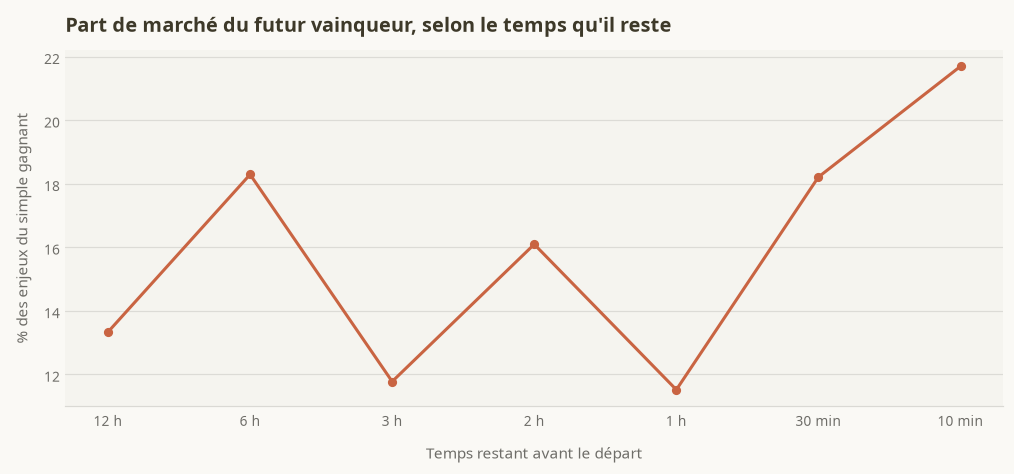

In [31]:
fig, ax = figure("Part de marché du futur vainqueur, selon le temps qu'il reste", (11, 4.2))
ordre_fenetres = [libelle for libelle in reversed(libelles) if libelle in vainqueur_fenetre.index]
ax.plot(
    ordre_fenetres,
    vainqueur_fenetre.loc[ordre_fenetres, "Part médiane du vainqueur"].to_numpy(),
    marker="o",
    color=THEME["primary"],
)
ax.set_ylabel("% des enjeux du simple gagnant")
ax.set_xlabel("Temps restant avant le départ")
plt.show()

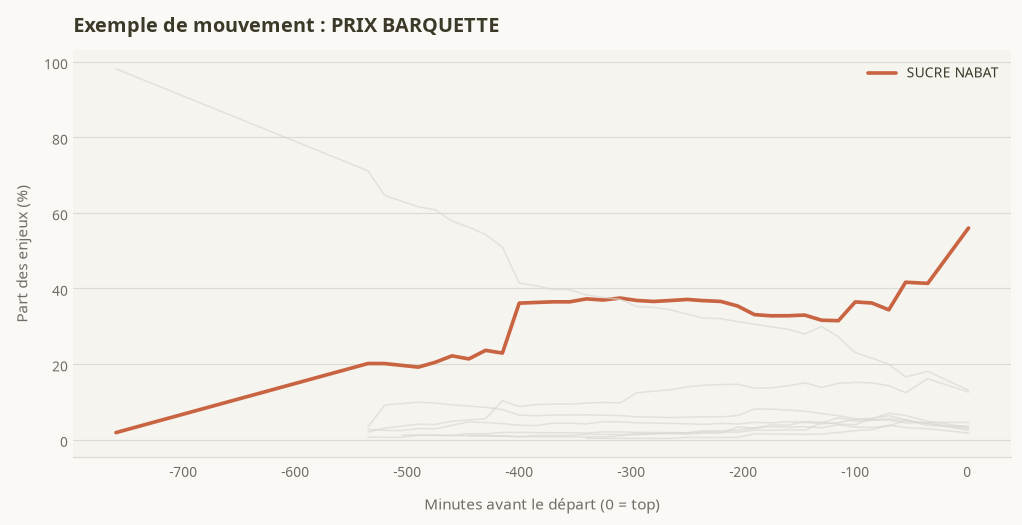

In [32]:
# Un exemple : la course où le vainqueur a le plus « monté »
premier_dernier_v = (
    suivi[suivi["est_vainqueur"]]
    .sort_values("update_time")
    .groupby("course_id", observed=True)
    .agg(part_debut=("part", "first"), part_fin=("part", "last"), nom=("nom_vainqueur", "first"))
)
premier_dernier_v["progression"] = premier_dernier_v["part_fin"] - premier_dernier_v["part_debut"]
exemple_id = premier_dernier_v["progression"].idxmax()
exemple = suivi[suivi["course_id"] == exemple_id].sort_values("instant")
libelle = courses.loc[courses["course_id"] == exemple_id, "libelle"]
titre_course = libelle.iloc[0] if len(libelle) else exemple_id

fig, ax = figure(f"Exemple de mouvement : {titre_course}", (11, 4.8))
for num, courbe in exemple.groupby("num_pmu"):
    est_g = bool(courbe["est_vainqueur"].iloc[0])
    ax.plot(
        -courbe["minutes_avant"],
        courbe["part"] * 100,
        color=THEME["primary"] if est_g else THEME["border"],
        linewidth=2.4 if est_g else 1.0,
        alpha=1 if est_g else 0.7,
        label=courbe["nom_vainqueur"].iloc[0] if est_g else None,
    )
ax.set_xlabel("Minutes avant le départ (0 = top)")
ax.set_ylabel("Part des enjeux (%)")
ax.legend()
plt.show()

**À retenir.** Le futur vainqueur est déjà un peu plus joué que les autres plusieurs heures
avant le top, et sa part **monte encore** à l'approche du départ. Le marché ne découvre pas le
gagnant à la dernière minute : il le confirme. Les mouvements les plus spectaculaires — un
cheval qui « vapeur » — restent l'exception, pas la règle.

<a id="nez"></a>
## 5. Le public a-t-il le nez fin ?

On compare trois regards, sur les mêmes courses :

- le **favori du matin** : le cheval le plus joué sur la première photo ;
- le **favori de la dernière minute** : le plus joué sur la dernière photo ;
- les chevaux qui **montent** (leur part d'enjeux augmente) ou **descendent**.

In [33]:
def favori_a(frame, quand):
    ordre = frame.sort_values("update_time")
    instant = ordre.groupby("course_id", observed=True)["update_time"].transform(quand)
    photo = ordre[ordre["update_time"] == instant]
    favoris = photo.sort_values("part").groupby("course_id", observed=True).last()
    return favoris


premier_favori = favori_a(suivi, "min")
dernier_favori = favori_a(suivi, "max")

profil_cheval = (
    suivi.sort_values("update_time")
    .groupby(["course_id", "num_pmu"], observed=True)
    .agg(
        part_debut=("part", "first"),
        part_fin=("part", "last"),
        enjeu_debut=("enjeu", "first"),
        enjeu_fin=("enjeu", "last"),
        est_vainqueur=("est_vainqueur", "max"),
        nom_vainqueur=("nom_vainqueur", "first"),
    )
)
profil_cheval["drift"] = profil_cheval["part_fin"] - profil_cheval["part_debut"]
profil_cheval["monte"] = profil_cheval["drift"] > 0

# argent nouveau : ce qui s'est ajouté sur le cheval / ce qui s'est ajouté sur la course
masse = (
    suivi.sort_values("update_time")
    .groupby("course_id", observed=True)
    .agg(masse_debut=("masse", "first"), masse_fin=("masse", "last"))
)
profil_cheval = profil_cheval.join(masse)
profil_cheval["flux"] = profil_cheval["enjeu_fin"] - profil_cheval["enjeu_debut"]
profil_cheval["flux_course"] = profil_cheval["masse_fin"] - profil_cheval["masse_debut"]
profil_cheval["part_du_flux"] = np.where(
    profil_cheval["flux_course"] > 0,
    profil_cheval["flux"] / profil_cheval["flux_course"],
    np.nan,
)

display(
    chiffres_cles(
        {
            "Le favori du matin gagne": f"{nombre(premier_favori['est_vainqueur'].mean() * 100, 1)} % des courses",
            "Le favori de la dernière minute gagne": f"{nombre(dernier_favori['est_vainqueur'].mean() * 100, 1)} % des courses",
            "Le favori a changé en cours de route": f"{nombre((premier_favori['num_pmu'] != dernier_favori['num_pmu']).mean() * 100, 1)} % des courses",
            "Quand un cheval monte, il gagne": f"{nombre(profil_cheval.loc[profil_cheval['monte'], 'est_vainqueur'].mean() * 100, 1)} % du temps",
            "Quand un cheval descend, il gagne": f"{nombre(profil_cheval.loc[~profil_cheval['monte'], 'est_vainqueur'].mean() * 100, 1)} % du temps",
        },
        "Trois lectures du « nez » du public",
    )
)

,
Le favori du matin gagne,"22,0 % des courses"
Le favori de la dernière minute gagne,"30,6 % des courses"
Le favori a changé en cours de route,"64,3 % des courses"
"Quand un cheval monte, il gagne","11,5 % du temps"
"Quand un cheval descend, il gagne","7,9 % du temps"


In [34]:
# Le vainqueur prend-il plus que sa part dans l'argent nouveau ?
flux_vainqueur = profil_cheval.loc[profil_cheval["est_vainqueur"], "part_du_flux"]
part_finale = profil_cheval.loc[profil_cheval["est_vainqueur"], "part_fin"]
display(
    chiffres_cles(
        {
            "Part finale médiane du vainqueur": f"{nombre(part_finale.median() * 100, 1)} %",
            "Part de l'argent nouveau allée sur le vainqueur": f"{nombre(flux_vainqueur.median() * 100, 1)} %",
            "L'argent nouveau est plus concentré sur lui": (
                "Oui" if flux_vainqueur.median() > part_finale.median() else "Non, pas nettement"
            ),
        },
        "L'argent qui arrive en cours de journée est-il plus malin que le stock ?",
    )
)

,
Part finale médiane du vainqueur,"15,9 %"
Part de l'argent nouveau allée sur le vainqueur,"15,5 %"
L'argent nouveau est plus concentré sur lui,"Non, pas nettement"


In [35]:
deciles = pd.qcut(profil_cheval["drift"], 8, duplicates="drop")
par_drift = profil_cheval.groupby(deciles, observed=True).agg(
    chevaux=("est_vainqueur", "size"),
    victoires=("est_vainqueur", "mean"),
    part_debut=("part_debut", "median"),
    part_fin=("part_fin", "median"),
)
par_drift["victoires"] *= 100
par_drift["part_debut"] *= 100
par_drift["part_fin"] *= 100
par_drift.index = [f"{int(i.left * 100):+d} à {int(i.right * 100):+d} pts" for i in par_drift.index]
par_drift.columns = ["Chevaux", "Victoires (%)", "Part au début (%)", "Part à la fin (%)"]
display(
    tableau(
        par_drift,
        "Plus un cheval « vapeur », plus il gagne — mais il partait déjà plus joué",
        formats={
            "Chevaux": lambda v: nombre(v),
            "Victoires (%)": lambda v: nombre(v, 1),
            "Part au début (%)": lambda v: nombre(v, 1),
            "Part à la fin (%)": lambda v: nombre(v, 1),
        },
        barres=["Victoires (%)"],
    )
)

,Chevaux,Victoires (%),Part au début (%),Part à la fin (%)
-95 à -14 pts,475,"12,6","36,7","8,3"
-14 à -5 pts,474,"10,5","15,4","5,4"
-5 à -2 pts,474,"6,1","8,3","4,3"
-2 à +0 pts,474,"3,8","4,6","3,3"
+0 à +0 pts,474,"3,8","2,5","2,6"
+0 à +2 pts,474,"5,1","2,7","4,2"
+2 à +6 pts,474,"9,7","3,9","8,1"
+6 à +54 pts,474,"24,1","6,6","20,1"


**À retenir.** Le public n'est pas myope. Le favori de la dernière minute gagne un peu plus
souvent que celui du matin, et un cheval dont la cote **raccourcit** gagne bien plus souvent
qu'un cheval que l'on délaisse. Mais ce n'est pas un oracle caché : les chevaux qui montent
étaient déjà plus joués au départ. L'argent nouveau confirme plus qu'il ne révèle.

On ne peut pas isoler un clan de parieurs « qui ont le nez fin ». On peut dire que **le
mouvement de la foule**, pris dans son ensemble, va dans le bon sens — et que ce mouvement
est déjà en grande partie dans la cote de 002.

<a id="courses"></a>
## 6. Quelles courses sont les plus intéressantes

In [36]:
def hhi(parts):
    return float((parts.to_numpy() ** 2).sum())


portraits = []
for course_id, bloc in suivi.groupby("course_id", observed=True):
    bloc = bloc.sort_values("update_time")
    premiere = bloc[bloc["update_time"] == bloc["update_time"].min()]
    derniere = bloc[bloc["update_time"] == bloc["update_time"].max()]
    fav_avant = premiere.sort_values("part").iloc[-1]
    fav_apres = derniere.sort_values("part").iloc[-1]
    vainqueur = bloc[bloc["est_vainqueur"]]
    if vainqueur.empty:
        continue
    favori_share = (
        bloc.groupby("update_time")
        .apply(lambda g: g["part"].max(), include_groups=False)
        .astype(float)
    )
    portraits.append(
        {
            "course_id": course_id,
            "libelle": courses.loc[courses["course_id"] == course_id, "libelle"].iloc[0],
            "discipline": derniere["discipline"].iloc[0],
            "masse_finale": derniere["masse"].iloc[0] / 100,
            "photos": bloc["update_time"].nunique(),
            "favori_stable": fav_avant["num_pmu"] == fav_apres["num_pmu"],
            "part_favori": fav_apres["part"],
            "part_vainqueur_debut": vainqueur.sort_values("update_time")["part"].iloc[0],
            "part_vainqueur_fin": vainqueur.sort_values("update_time")["part"].iloc[-1],
            "volatilite_favori": favori_share.std(),
            "concentration": hhi(derniere.set_index("num_pmu")["part"]),
            "fenetre_heures": (bloc["update_time"].max() - bloc["update_time"].min()) / 3_600_000,
        }
    )

portrait = pd.DataFrame(portraits).set_index("course_id")
portrait["progression_vainqueur"] = portrait["part_vainqueur_fin"] - portrait["part_vainqueur_debut"]

interessantes = pd.Series(
    {
        "Plus grosse masse d'enjeux": portrait["masse_finale"].idxmax(),
        "Favori le plus chahuté": portrait["volatilite_favori"].idxmax(),
        "Vainqueur qui a le plus monté": portrait["progression_vainqueur"].idxmax(),
        "Marché le plus concentré": portrait["concentration"].idxmax(),
        "Marché le plus étalé": portrait["concentration"].idxmin(),
    }
)
fiche = pd.DataFrame(
    {
        "Course": [portrait.loc[cid, "libelle"] for cid in interessantes],
        "Discipline": [portrait.loc[cid, "discipline"] for cid in interessantes],
        "Masse finale (€)": [portrait.loc[cid, "masse_finale"] for cid in interessantes],
        "Part du favori (%)": [portrait.loc[cid, "part_favori"] * 100 for cid in interessantes],
    },
    index=interessantes.index,
)
display(
    tableau(
        fiche,
        "Cinq courses qui sortent du lot",
        formats={
            "Course": "{}",
            "Discipline": "{}",
            "Masse finale (€)": lambda v: nombre(v, 0),
            "Part du favori (%)": lambda v: nombre(v, 1),
        },
    )
)

,Course,Discipline,Masse finale (€),Part du favori (%)
Plus grosse masse d'enjeux,QATAR PRIX DE LA REINE MARGUERITE PRESENTE PAR LE PARISIEN,PLAT,67 245,"23,3"
Favori le plus chahuté,PRIX DES JONQUILLES NORVEGE,ATTELE,1 999,"17,6"
Vainqueur qui a le plus monté,PRIX BARQUETTE,PLAT,18 875,"56,0"
Marché le plus concentré,QATAR PRIX FOY,PLAT,7 451,"70,0"
Marché le plus étalé,PRIX DE LA FONTAINE MORNY,PLAT,5 744,"12,0"


In [37]:
resume_courses = pd.DataFrame(
    {
        "Masse médiane (€)": [portrait["masse_finale"].median()],
        "Le favori reste le même": [portrait["favori_stable"].mean() * 100],
        "Part médiane du favori": [portrait["part_favori"].median() * 100],
        "Part médiane du vainqueur, au début": [portrait["part_vainqueur_debut"].median() * 100],
        "Part médiane du vainqueur, à la fin": [portrait["part_vainqueur_fin"].median() * 100],
    },
    index=["Ensemble des courses suivies"],
).T
display(
    tableau(
        resume_courses,
        "Portrait type d'une course suivie en direct",
        formats={resume_courses.columns[0]: lambda v: nombre(v, 1)},
    )
)

,Ensemble des courses suivies
Masse médiane (€),"5 024,5"
Le favori reste le même,"35,2"
Part médiane du favori,"30,7"
"Part médiane du vainqueur, au début","14,3"
"Part médiane du vainqueur, à la fin","15,9"


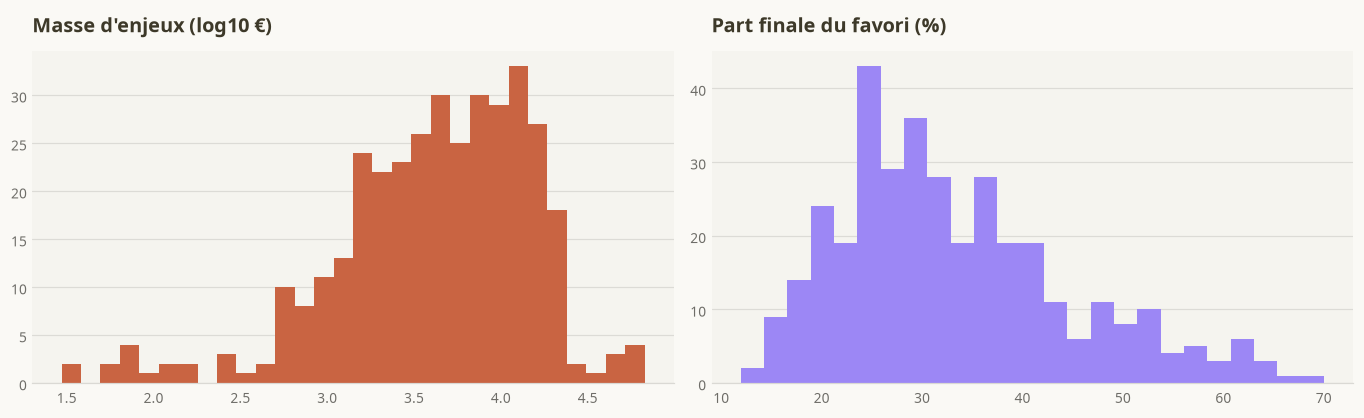

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.9))
axes[0].hist(np.log10(portrait["masse_finale"].clip(lower=1)), bins=30, color=THEME["primary"])
axes[0].set_title("Masse d'enjeux (log10 €)")
axes[1].hist(portrait["part_favori"] * 100, bins=25, color=ds.color_cycle(2)[1])
axes[1].set_title("Part finale du favori (%)")
fig.tight_layout()
plt.show()

**À retenir.** Une course « intéressante » pour lire le marché, ce n'est pas forcément la plus
dotée. C'est celle où **l'argent hésite** : favori qui change, part du leader qui oscille,
vainqueur qui n'était pas en tête le matin. À l'inverse, une masse énorme sur un cheval déjà
seul au monde apprend peu : le résultat y est presque écrit. Les quintés et les grandes
épreuves pèsent lourd, mais les courses serrées, même plus modestes, sont plus instructives
pour un modèle.

<a id="clusters"></a>
## 7. Quatre visages du marché

Sans connaître les parieurs, on peut quand même regrouper les *courses* selon la façon dont
la foule s'y est comportée. Quatre familles suffisent à résumer le film.

In [39]:
features = portrait[
    ["masse_finale", "part_favori", "volatilite_favori", "concentration", "progression_vainqueur", "fenetre_heures"]
].copy()
features["log_masse"] = np.log10(features["masse_finale"].clip(lower=1))
features["favori_a_change"] = (~portrait["favori_stable"]).astype(float)
X = features[["log_masse", "part_favori", "volatilite_favori", "concentration", "progression_vainqueur", "favori_a_change"]].fillna(0)

modele = KMeans(n_clusters=4, random_state=0, n_init=10)
portrait["cluster"] = modele.fit_predict(StandardScaler().fit_transform(X))

# ordonner les groupes du plus fréquent au moins fréquent, puis les nommer d'après leur profil
stats = portrait.groupby("cluster").agg(
    courses=("libelle", "size"),
    masse=("masse_finale", "median"),
    part_favori=("part_favori", "median"),
    volatilite=("volatilite_favori", "median"),
    favori_stable=("favori_stable", "mean"),
    progression=("progression_vainqueur", "median"),
    vainqueur_trouve=("part_vainqueur_fin", "median"),
)

def nommer(ligne):
    if ligne["favori_stable"] >= 0.9:
        return "Le boulevard : favori incontesté"
    if ligne["part_favori"] >= 0.45:
        return "Le favori écrasant"
    if ligne["progression"] < 0:
        return "Le leurre : le vainqueur perd des enjeux"
    return "Le rattrapage : l'argent bascule vers le vainqueur"


stats["lecture"] = stats.apply(nommer, axis=1)
portrait["lecture"] = portrait["cluster"].map(stats["lecture"])

vue = stats.set_index("lecture")[
    ["courses", "masse", "part_favori", "volatilite", "favori_stable", "progression"]
]
vue["part_favori"] *= 100
vue["favori_stable"] *= 100
vue["progression"] *= 100
vue.columns = [
    "Courses",
    "Masse médiane (€)",
    "Part du favori (%)",
    "Volatilité du favori",
    "Favori inchangé (%)",
    "Progression du vainqueur (pts)",
]
display(
    tableau(
        vue.sort_values("Courses", ascending=False),
        "Quatre manières dont le public habite une course",
        formats={
            "Courses": lambda v: nombre(v),
            "Masse médiane (€)": lambda v: nombre(v, 0),
            "Part du favori (%)": lambda v: nombre(v, 1),
            "Volatilité du favori": lambda v: nombre(v, 3),
            "Favori inchangé (%)": lambda v: nombre(v, 0),
            "Progression du vainqueur (pts)": lambda v: nombre(v, 1),
        },
        barres=["Courses"],
    )
)

,Courses,Masse médiane (€),Part du favori (%),Volatilité du favori,Favori inchangé (%),Progression du vainqueur (pts)
lecture,,,,,,
Le rattrapage : l'argent bascule vers le vainqueur,138,7 607,"25,5","0,063",0,"4,3"
Le boulevard : favori incontesté,87,7 048,"31,0","0,073",100,"-0,1"
Le leurre : le vainqueur perd des enjeux,69,1 539,"29,8","0,189",10,"-7,7"
Le favori écrasant,64,4 149,"51,7","0,100",50,"4,6"


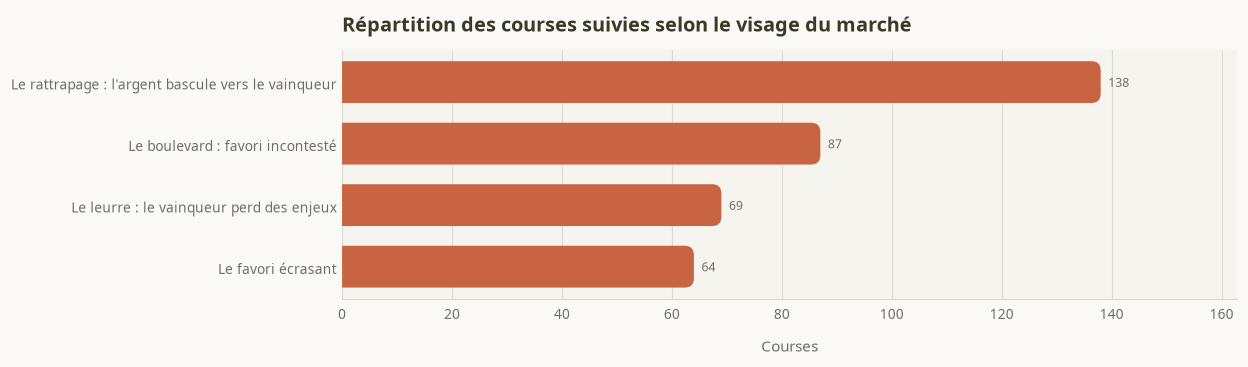

In [40]:
fig, ax = barres(
    vue["Courses"],
    "Répartition des courses suivies selon le visage du marché",
    "Courses",
    fmt="{:,.0f}",
)
plt.show()

**À retenir.** Le cluster le plus peuplé est souvent le plus ennuyeux pour un modèle : un
favori qui ne bouge plus, une masse déjà posée. Les groupes utiles sont les autres — là où le
marché **change d'avis** ou là où le vainqueur **rattrape** son retard de cote. C'est dans
ces courses-là qu'un signal temporel (la dérive de la cote) a une chance d'ajouter quelque
chose à la simple photo de 002.

Toujours pas de « club de parieurs lucides ». En revanche, il existe des *régimes de marché*
très différents. Les traiter tous de la même façon serait une erreur de modélisation.

<a id="verdict"></a>
## 8. Verdict

In [41]:
verdict = pd.DataFrame(
    [
        (
            "Suivre l'évolution d'une cote",
            "Oui, sur ce périmètre",
            "Des dizaines de photos par course, sur une dizaine d'heures.",
        ),
        (
            "Repérer un clan de parieurs lucides",
            "Non, pas avec cette table",
            "Les enjeux sont agrégés. On voit la foule, pas les personnes.",
        ),
        (
            "La foule, elle, a-t-elle du nez ?",
            "Un peu, surtout en confirmant",
            "Le favori de la dernière minute fait mieux que celui du matin. L'argent nouveau va dans le bon sens, sans révolution.",
        ),
        (
            "Certaines courses sont plus riches à lire",
            "Oui",
            "Celles où le favori vacille, où le vainqueur monte, où la masse n'est pas déjà concentrée.",
        ),
        (
            "S'en servir comme variable d'un modèle",
            "Oui, en complément",
            "La dérive de cote et le régime de marché (calme / chahuté) sont des features que la cote finale ne résume pas tout à fait.",
        ),
        (
            "En tirer une loi sur l'année 2025-2026",
            "Non",
            "Deux semaines de direct ne font pas un historique. Il faudrait que le suivi tourne en continu.",
        ),
    ],
    columns=["Question", "Réponse", "Pourquoi"],
).set_index("Question")
display(
    tableau(
        verdict,
        "Ce que le marché en direct autorise — et ce qu'il n'autorise pas",
        formats={"Réponse": "{}", "Pourquoi": "{}"},
    )
)

,Réponse,Pourquoi
Question,,
Suivre l'évolution d'une cote,"Oui, sur ce périmètre","Des dizaines de photos par course, sur une dizaine d'heures."
Repérer un clan de parieurs lucides,"Non, pas avec cette table","Les enjeux sont agrégés. On voit la foule, pas les personnes."
"La foule, elle, a-t-elle du nez ?","Un peu, surtout en confirmant","Le favori de la dernière minute fait mieux que celui du matin. L'argent nouveau va dans le bon sens, sans révolution."
Certaines courses sont plus riches à lire,Oui,"Celles où le favori vacille, où le vainqueur monte, où la masse n'est pas déjà concentrée."
S'en servir comme variable d'un modèle,"Oui, en complément",La dérive de cote et le régime de marché (calme / chahuté) sont des features que la cote finale ne résume pas tout à fait.
En tirer une loi sur l'année 2025-2026,Non,Deux semaines de direct ne font pas un historique. Il faudrait que le suivi tourne en continu.


**Le nez fin, s'il existe, est celui de la foule en mouvement, pas celui d'un groupe
identifiable.** L'argent qui arrive en cours de journée se pose un peu plus sur le futur
vainqueur que l'argent déjà là le matin. Ce n'est pas un scoop caché dans un coin de la
table : c'est une confirmation progressive, visible à l'œil nu sur la cote.

Pour la modélisation, le vrai apport n'est donc pas « battre le simple gagnant avec un
cluster de cracks ». C'est **enrichir la photo** de 002 d'un petit film : la cote a-t-elle
raccourci ou allongé ? le favori a-t-il changé ? le marché était-il calme ou chahuté ?
Ces questions n'ont de réponse que sur les courses effectivement suivies en direct — aujourd'hui
une poignée de journées. Si ce suivi continue, ce 003 devient un gisement. S'il reste une
fenêtre de deux semaines, il reste une belle illustration, pas encore une loi.